# Frequency scan of the final pulse in a truncated LMT sequence

This notebook reuses the same lab pulse sequence as `true_LMT_trajectory.ipynb`,
truncates it to the first `N` pulses, and then scans the laser frequency
(detuning) of the **final, Nth pulse** over +/- 10 recoil frequencies.

For each detuning we run the full Borde-frame simulation for an *ideal atom* --
one with no extra velocity (the centre of the velocity distribution, i.e.
exactly the `INITIAL_VELOCITY_Z` the sequence was designed for) and at the
centre of the cloud (`position = 0`).

**Frame note (gravity / Doppler).** `build_sequence_from_lab_pulse_dump`
already removes the full Doppler shift `v(t)/lambda` of the central falling
atom -- both the constant `v0` part *and* the gravity ramp `g*t` -- with the
opposite sign on the up vs down beam, transforming the lab pulse train into the
central atom's rest frame. It also assumes the first pulse is on resonance
there. So the ideal atom must be simulated at **`vz = 0`** in that frame:
passing `v0` again would double-count the constant Doppler and shift the
resonance by `+/- v0/lambda ~ +/- 0.5` recoil, oppositely for the up vs down
beam. (The gravity ramp is what keeps the resonance time-independent; flipping
its sign would move late pulses by tens of recoils.)

Each plot shows two traces: one where the final pulse is delivered on the **up**
beam (`k = +1`) and one where it is on the **down** beam (`k = -1`). We repeat
the plot for `N = 1, 2, 3, 4, 5`.

In [1]:
import sys
import dataclasses

sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq

## Lab pulse dump

Same dump and `INITIAL_VELOCITY_Z` as `true_LMT_trajectory.ipynb`.

In [2]:
pulse_sequence = [[[1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0], [4936, 2691191, 2771190, 2838189, 2918188, 2985187, 3065186, 3132185, 3212184, 3279183, 3359182, 3426181, 3506180, 3573179, 3653178, 3720177, 3800176, 4077207, 4122991, 4286111, 4392695, 4722709, 4809244, 4922367, 5030207, 5108734, 5221855, 5328439, 5508438, 5594973, 5908111, 6019623], [380000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 34000, 99999, 99999, 68000, 68000, 99999, 99999, 68000, 99999, 99999, 68000, 68000, 99999, 99999, 34000], [80000000, 79971814, 80020109, 79988550, 80003372, 80005286, 79986636, 80022022, 79969900, 80038758, 79953164, 80055494, 79936428, 80072230, 79919692, 80088966, 79902956, 80027353, 79983322, 79966812, 80004123, 79999490, 79974157, 79994546, 80013772, 79978362, 79998751, 80028585, 80026058, 80003989, 79989586, 80000149], [200000000, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800], [99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]]

(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint,
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

# Initial (t=0) atomic velocity along z, in m/s. The sequence detunings are
# built to compensate the Doppler shift of an atom moving at this velocity, so
# the "ideal" atom is the one travelling at exactly INITIAL_VELOCITY_Z.
INITIAL_VELOCITY_Z = -1.6888e-3  # m/s

In [3]:
sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
)

# Skip the first freefall, exactly as in true_LMT_trajectory.ipynb, so the
# sequence starts on the first pulse.
sequence = sequence[1:]

print(f'{len(sequence)} events, '
      f'{sum(isinstance(e, seq.Pulse) for e in sequence)} pulses')

63 events, 32 pulses


## Truncate and scan helpers

`truncate_to_n_pulses` keeps every event up to and including the Nth pulse (so
any trailing freefall after the Nth pulse is dropped -- it does not change the
excitation fraction). `scan_final_pulse` then sweeps the final pulse's detuning
for a chosen beam direction `k`.

In [4]:
def truncate_to_n_pulses(events, n):
    """Return the prefix of `events` ending on the nth Pulse (1-indexed)."""
    out = []
    n_pulses = 0
    for event in events:
        out.append(event)
        if isinstance(event, seq.Pulse):
            n_pulses += 1
            if n_pulses == n:
                return out
    raise ValueError(
        f'Sequence only contains {n_pulses} pulses, cannot truncate to {n}'
    )


def scan_final_pulse(events, n, k, detuning_offsets_recoils):
    """Excitation fraction vs final-pulse detuning for beam direction `k`.

    The first N-1 pulses are left untouched; only the final (Nth) pulse has its
    beam direction set to `k` and its detuning swept about the design value.

    The ideal atom is simulated at vz = 0: the sequence builder has already
    transformed into the central falling atom's rest frame (it subtracts the
    full v(t)/lambda Doppler), so the central atom carries no residual Doppler
    here. Passing INITIAL_VELOCITY_Z instead would double-count the constant
    v0 Doppler.
    """
    truncated = truncate_to_n_pulses(events, n)
    base_detuning_hz = truncated[-1].detuning_hz

    excitation_fraction = np.empty(len(detuning_offsets_recoils))
    for i, offset in enumerate(detuning_offsets_recoils):
        detuning_hz = base_detuning_hz + offset * sim.RECOIL_FREQUENCY_HZ
        scanned = list(truncated)
        scanned[-1] = dataclasses.replace(
            scanned[-1], k=k, detuning_hz=detuning_hz
        )
        excitation_fraction[i] = (
            seq.calculate_excited_fraction_for_pulse_sequence(
                scanned,
                velocity=(0.0, 0.0, 0.0),
                position=(0.0, 0.0, 0.0),
            )
        )
    return excitation_fraction

## Scan the final-pulse detuning for N = 1..5

Detuning offsets run over +/- 10 recoil frequencies relative to the design
detuning of the final pulse. Each panel overlays the up-beam (`k = +1`) and
down-beam (`k = -1`) results.

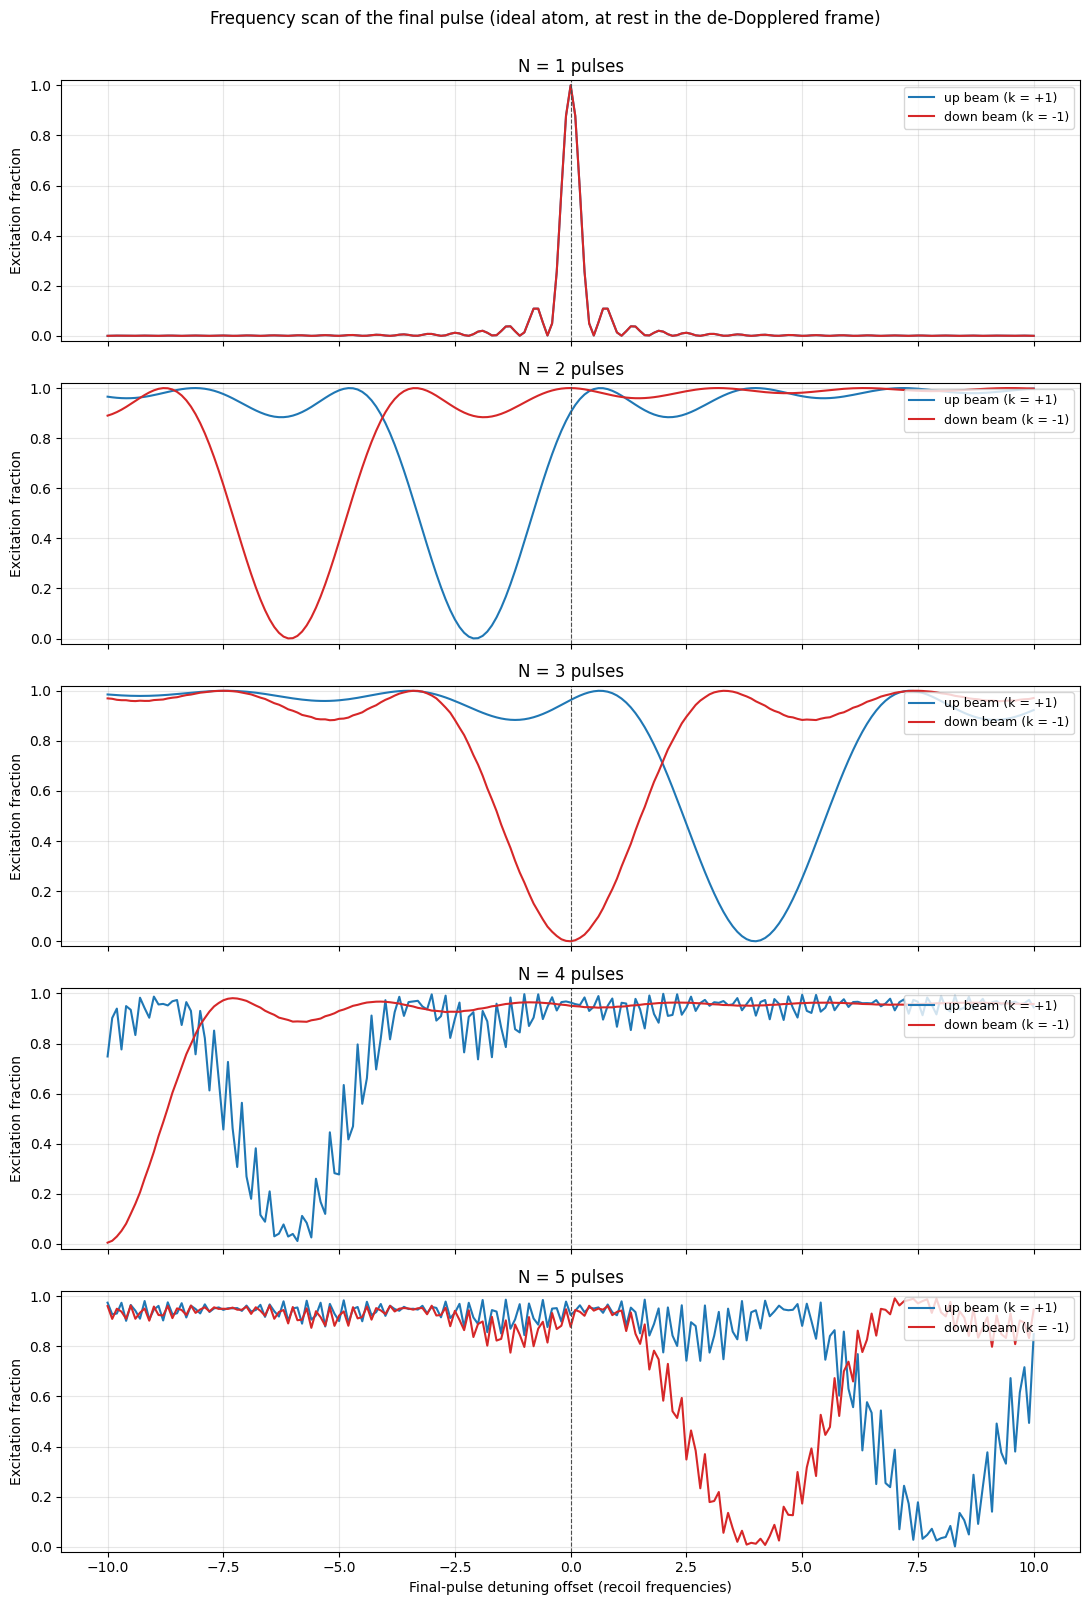

In [5]:
scan_halfwidth_recoils = 10.0
n_points = 201
N_values = [1, 2, 3, 4, 5]

detuning_offsets_recoils = np.linspace(
    -scan_halfwidth_recoils, scan_halfwidth_recoils, n_points
)

fig, axes = plt.subplots(
    len(N_values), 1, figsize=(11, 3.2 * len(N_values)), sharex=True
)

for ax, N in zip(axes, N_values):
    exc_up = scan_final_pulse(sequence, N, +1, detuning_offsets_recoils)
    exc_down = scan_final_pulse(sequence, N, -1, detuning_offsets_recoils)

    ax.plot(detuning_offsets_recoils, exc_up,
            color='tab:blue', label='up beam (k = +1)')
    ax.plot(detuning_offsets_recoils, exc_down,
            color='tab:red', label='down beam (k = -1)')
    ax.axvline(0.0, color='0.3', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Excitation fraction')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'N = {N} pulses')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Final-pulse detuning offset (recoil frequencies)')
fig.suptitle(
    'Frequency scan of the final pulse '
    '(ideal atom, at rest in the de-Dopplered frame)',
    y=1.0,
)
plt.tight_layout()
plt.show()